<a href="https://colab.research.google.com/github/siva567-pixel/Intermediate_Assessment_2_HR_Analytics/blob/main/Intermediate_Assessment_2_HR_Analytics_sivankutty.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [39]:
import numpy as np
import pandas as pd

In [40]:
train = pd.read_csv('/content/drive/MyDrive/DSA/Case study/train_LZdllcl.csv')
test = pd.read_csv('/content/drive/MyDrive/DSA/Case study/test_2umaH9m.csv')
sample = pd.read_csv('/content/drive/MyDrive/DSA/Case study/sample_submission_M0L0uXE.csv')

In [41]:
train = pd.DataFrame(train)
test = pd.DataFrame(test)

In [42]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


**T R A I N - D A T A**

In [43]:
print(train.shape)
print(train.head())
print(train.dtypes)

(54808, 14)
   employee_id         department     region         education gender  \
0        65438  Sales & Marketing   region_7  Master's & above      f   
1        65141         Operations  region_22        Bachelor's      m   
2         7513  Sales & Marketing  region_19        Bachelor's      m   
3         2542  Sales & Marketing  region_23        Bachelor's      m   
4        48945         Technology  region_26        Bachelor's      m   

  recruitment_channel  no_of_trainings  age  previous_year_rating  \
0            sourcing                1   35                   5.0   
1               other                1   30                   5.0   
2            sourcing                1   34                   3.0   
3               other                2   39                   1.0   
4               other                1   45                   3.0   

   length_of_service  KPIs_met >80%  awards_won?  avg_training_score  \
0                  8              1            0              

In [44]:
print(train.isnull().sum())

employee_id                0
department                 0
region                     0
education               2409
gender                     0
recruitment_channel        0
no_of_trainings            0
age                        0
previous_year_rating    4124
length_of_service          0
KPIs_met >80%              0
awards_won?                0
avg_training_score         0
is_promoted                0
dtype: int64


In [45]:
#Missing Values

education_mode = train['education'].mode()[0]
train['education'] = train['education'].fillna(education_mode)

rating_median = train['previous_year_rating'].median()
train['previous_year_rating'] = train['previous_year_rating'].fillna(rating_median)

In [46]:
print(train.duplicated().sum())

0


In [47]:
train['employee_id'].value_counts()

,count
employee_id,
51526,1
65438,1
65141,1
7513,1
2542,1
...,...
60051,1
49017,1
29934,1


In [48]:
#drop column employee_id

train.drop('employee_id', axis=1, inplace=True)

In [49]:
train.head()

,department,region,education,gender,recruitment_channel,no_of_trainings,age,previous_year_rating,length_of_service,KPIs_met >80%,awards_won?,avg_training_score,is_promoted
0,Sales & Marketing,region_7,Master's & above,f,sourcing,1,35,5.0,8,1,0,49,0
1,Operations,region_22,Bachelor's,m,other,1,30,5.0,4,0,0,60,0
2,Sales & Marketing,region_19,Bachelor's,m,sourcing,1,34,3.0,7,0,0,50,0
3,Sales & Marketing,region_23,Bachelor's,m,other,2,39,1.0,10,0,0,50,0
4,Technology,region_26,Bachelor's,m,other,1,45,3.0,2,0,0,73,0


In [50]:
import matplotlib.pyplot as plt
import seaborn as sns
vis_columns = [
    'age',
    'avg_training_score',
    'length_of_service',
]

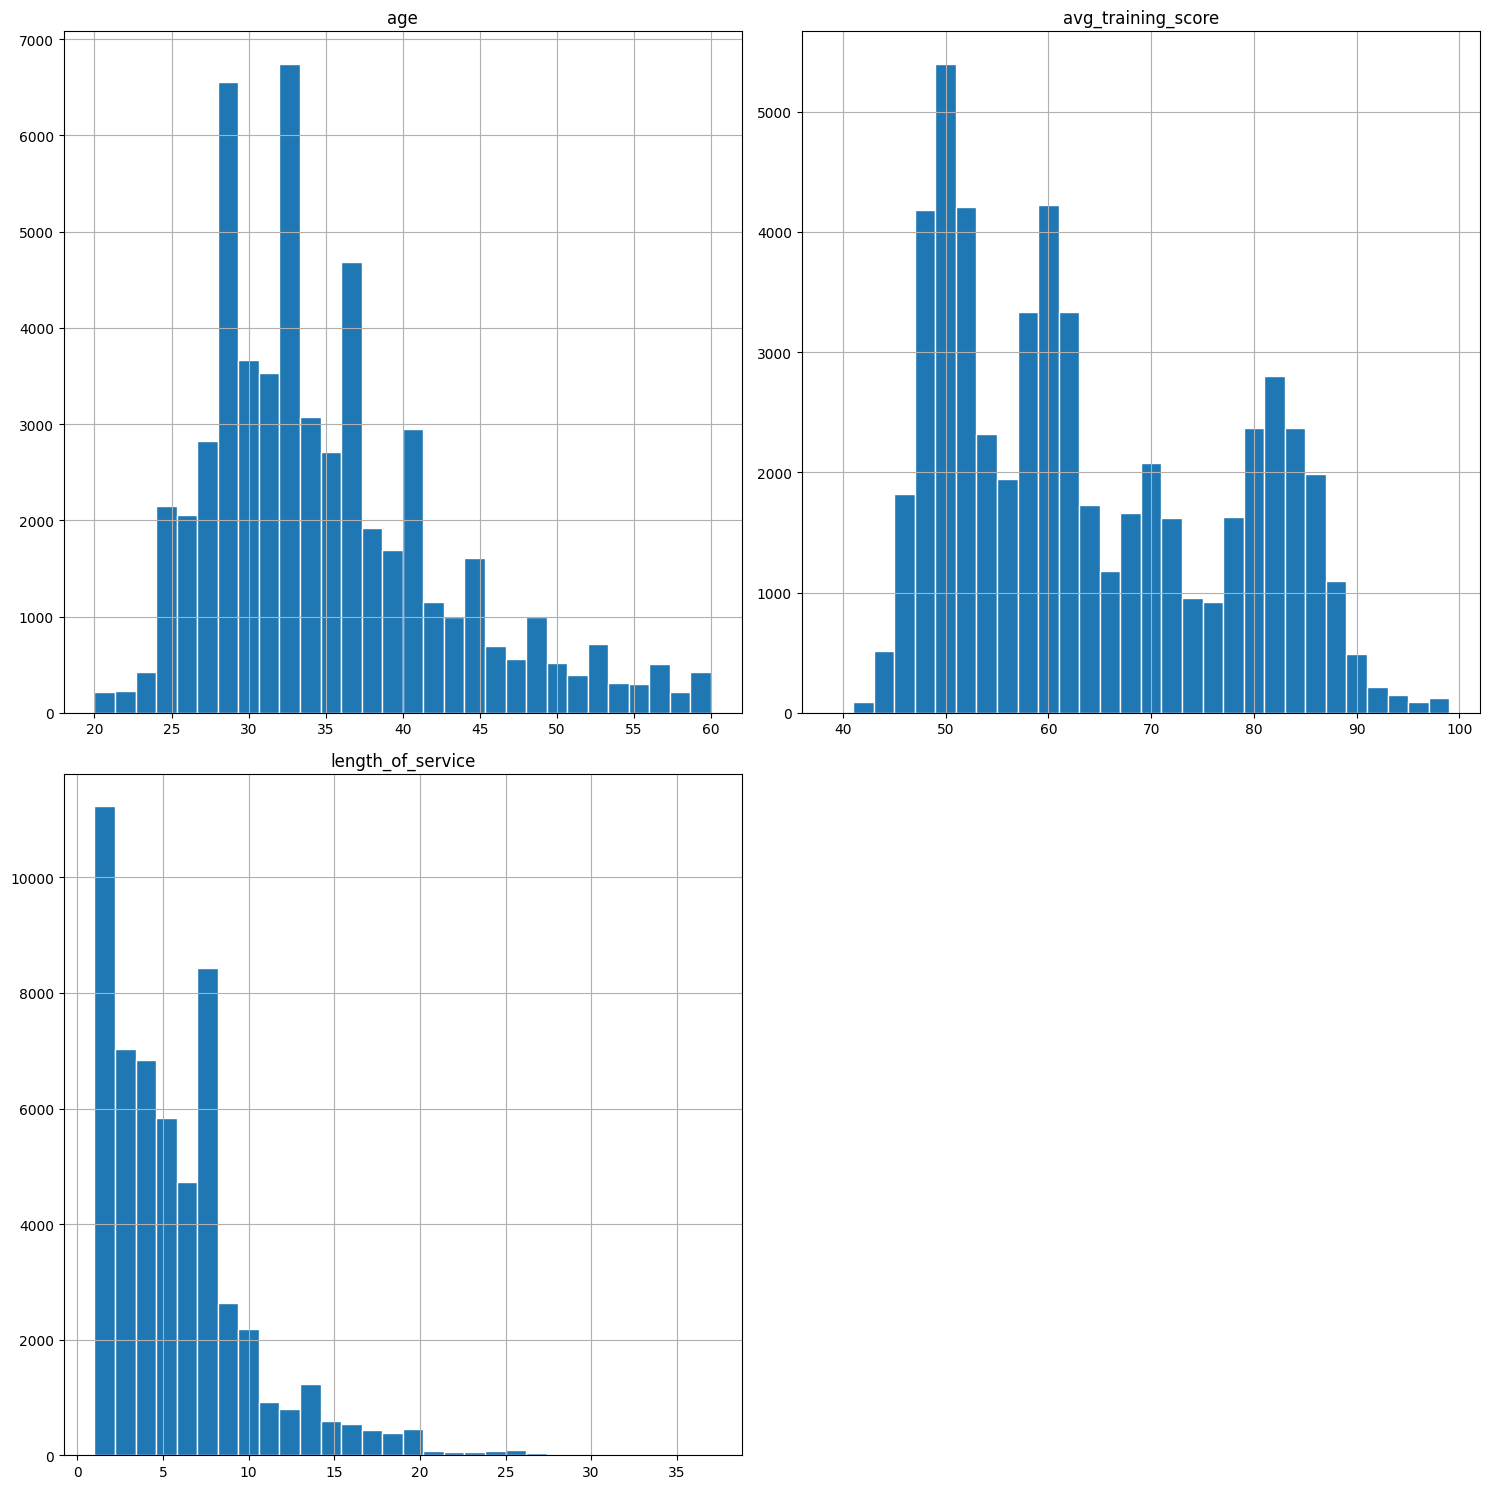

In [51]:
#histplot

train[vis_columns].hist(
    figsize=(15, 15),
    bins=30,
    edgecolor='white'
)
plt.tight_layout()
plt.show()

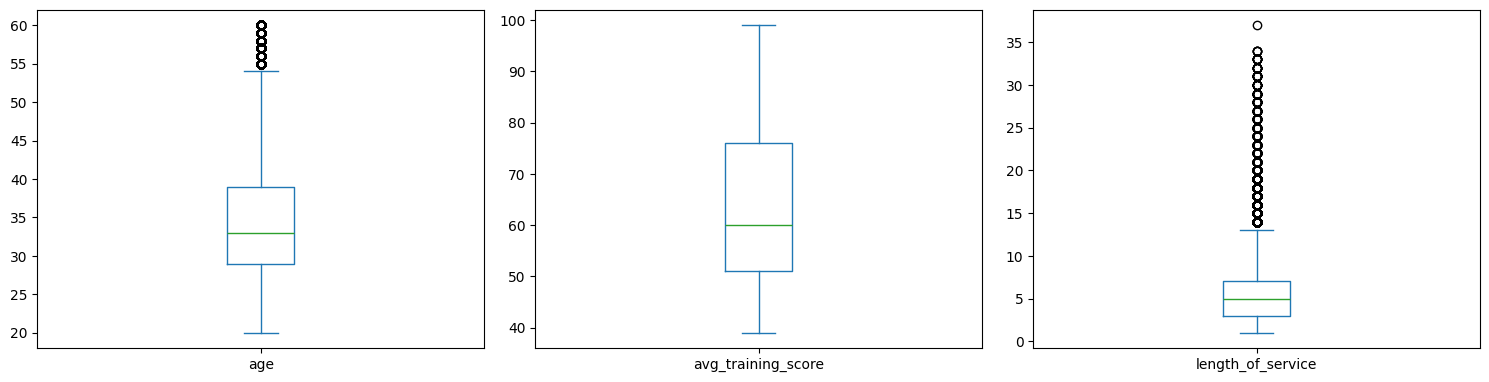

In [52]:
train[vis_columns].plot(
    kind='box',
    subplots=True,
    layout=(4, 3),
    figsize=(15, 15),
    sharex=False,
    sharey=False
)
plt.tight_layout()
plt.show()

In [53]:
#Outlier Detection
def find_outliers(vis_columns):
    Q1 = train[vis_columns].quantile(0.25)
    Q3 = train[vis_columns].quantile(0.75)
    IQR = Q3 - Q1

    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR
    return train[(train[vis_columns] < lower) | (train[vis_columns] > upper)]
    return lower,upper

#outliers in age
outliers_age = find_outliers('age')
print("Outliers in age:",len(outliers_age))

#outliers in length_of_service
outliers_length_of_service = find_outliers('length_of_service')
print("Outliers in length_of_service:",len(outliers_length_of_service))

#outliers in avg_training_score
outliers_avg_training_score = find_outliers('avg_training_score')
print("Outliers in avg_training_score:",len(outliers_avg_training_score))

Outliers in age: 1435
Outliers in length_of_service: 3489
Outliers in avg_training_score: 0


In [54]:
#Handling Outliers
# Create a copy of the training data to apply outlier handling safely

def cap_outliers(train, vis_columns):
    Q1 = train[vis_columns].quantile(0.25)
    Q3 = train[vis_columns].quantile(0.75)
    IQR = Q3 - Q1

    lower_boundary = Q1 - 1.5 * IQR
    upper_boundary = Q3 + 1.5 * IQR

# Cap values exceeding upper or lower boundaries
    train[vis_columns] = np.where(train[vis_columns] > upper_boundary, upper_boundary,
                          np.where(train[vis_columns] < lower_boundary, lower_boundary, train[vis_columns]))
    return train

# Cap outliers in 'age' and 'length_of_service'
train = cap_outliers(train, 'age')
train = cap_outliers(train, 'length_of_service')


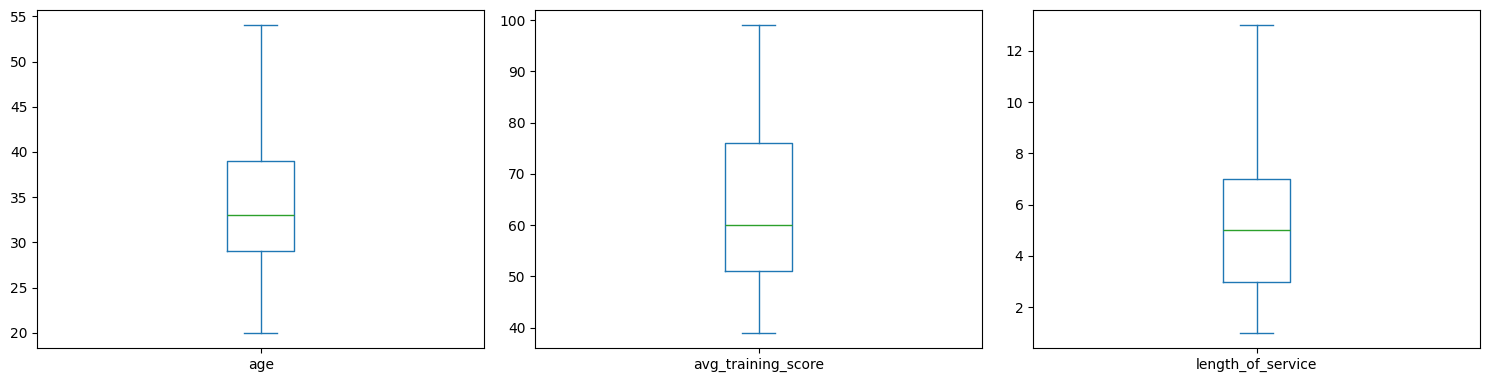

In [55]:
train[vis_columns].plot(
    kind='box',
    subplots=True,
    layout=(4, 3),
    figsize=(15, 15),
    sharex=False,
    sharey=False
)
plt.tight_layout()
plt.show()

In [56]:
#Encoding
from sklearn.preprocessing import LabelEncoder

train['gender'] = train['gender'].map({'m': 0, 'f': 1})

In [57]:
print(train['department'].value_counts(),
train['region'].value_counts(),
train['education'].value_counts(),
train['recruitment_channel'].value_counts())

department
Sales & Marketing    16840
Operations           11348
Technology            7138
Procurement           7138
Analytics             5352
Finance               2536
HR                    2418
Legal                 1039
R&D                    999
Name: count, dtype: int64 region
region_2     12343
region_22     6428
region_7      4843
region_15     2808
region_13     2648
region_26     2260
region_31     1935
region_4      1703
region_27     1659
region_16     1465
region_28     1318
region_11     1315
region_23     1175
region_29      994
region_32      945
region_19      874
region_20      850
region_14      827
region_25      819
region_17      796
region_5       766
region_6       690
region_30      657
region_8       655
region_10      648
region_1       610
region_24      508
region_12      500
region_9       420
region_21      411
region_3       346
region_34      292
region_33      269
region_18       31
Name: count, dtype: int64 education
Bachelor's          39078
Maste

In [58]:
education_mapping = {
    'Below Secondary': 0,
    "Bachelor's": 1,
    "Master's & above": 2
}
train['education'] = train['education'].map(education_mapping)

In [59]:
train = pd.get_dummies(
    train,
    columns=['recruitment_channel', 'department'],
    drop_first=True,
    dtype=int,
)

In [60]:
from sklearn.preprocessing import TargetEncoder

# Initialize the scikit-learn Target Encoder
encoder = TargetEncoder()

# Fit and transform the region column
train['region'] = encoder.fit_transform(train[['region']], train['is_promoted'])

In [61]:
train.head()

,region,education,gender,no_of_trainings,age,previous_year_rating,length_of_service,KPIs_met >80%,awards_won?,avg_training_score,...,recruitment_channel_referred,recruitment_channel_sourcing,department_Finance,department_HR,department_Legal,department_Operations,department_Procurement,department_R&D,department_Sales & Marketing,department_Technology
0,0.106694,2,1,1,35.0,5.0,8.0,1,0,49,...,0,1,0,0,0,0,0,0,1,0
1,0.115347,1,0,1,30.0,5.0,4.0,0,0,60,...,0,0,0,0,0,1,0,0,0,0
2,0.060198,1,0,1,34.0,3.0,7.0,0,0,50,...,0,1,0,0,0,0,0,0,1,0
3,0.117478,1,0,2,39.0,1.0,10.0,0,0,50,...,0,0,0,0,0,0,0,0,1,0
4,0.065762,1,0,1,45.0,3.0,2.0,0,0,73,...,0,0,0,0,0,0,0,0,0,1


In [62]:
from sklearn.model_selection import train_test_split

x = train.drop('is_promoted', axis=1)
y = train['is_promoted']

x_train, x_test, y_train, y_test = train_test_split(
    x, y, test_size=0.2, random_state=42, stratify=y
)

print(x_train.shape, x_test.shape, y_train.shape, y_test.shape)
y.value_counts()

(43846, 20) (10962, 20) (43846,) (10962,)


,count
is_promoted,
0,50140
1,4668


In [63]:
from imblearn.over_sampling import SMOTE

# 1. Initialize SMOTE
smote = SMOTE(random_state=42)

# 2. Resample ONLY the training data
x_train_resampled, y_train_resampled = smote.fit_resample(x_train, y_train)

print("Before SMOTE:", y_train.value_counts())
print("After SMOTE:", pd.Series(y_train_resampled).value_counts())

Before SMOTE: is_promoted
0    40112
1     3734
Name: count, dtype: int64
After SMOTE: is_promoted
0    40112
1    40112
Name: count, dtype: int64


In [64]:
#Scaling
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
scale_cols = [
    'age',
    'avg_training_score',
    'length_of_service',
    'previous_year_rating',
    'no_of_trainings',
]

x_train_resampled[scale_cols] = scaler.fit_transform(
    x_train_resampled[scale_cols]
)
x_test[scale_cols] = scaler.transform(x_test[scale_cols])

In [65]:
#Importing Classification models
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.ensemble import RandomForestClassifier

In [66]:
from sklearn.metrics import f1_score

Logistic Regression

In [67]:
#Logistic Regression
log_model = LogisticRegression()
log_model.fit(x_train_resampled, y_train_resampled)
y_pred = log_model.predict(x_test)

In [68]:
from sklearn.metrics import accuracy_score,confusion_matrix,classification_report
print(confusion_matrix(y_test, y_pred))
print("F1 Score:", f1_score(y_test, y_pred))
print(classification_report(y_test, y_pred))

[[7740 2288]
 [ 403  531]]
F1 Score: 0.2829736211031175
              precision    recall  f1-score   support

           0       0.95      0.77      0.85     10028
           1       0.19      0.57      0.28       934

    accuracy                           0.75     10962
   macro avg       0.57      0.67      0.57     10962
weighted avg       0.89      0.75      0.80     10962



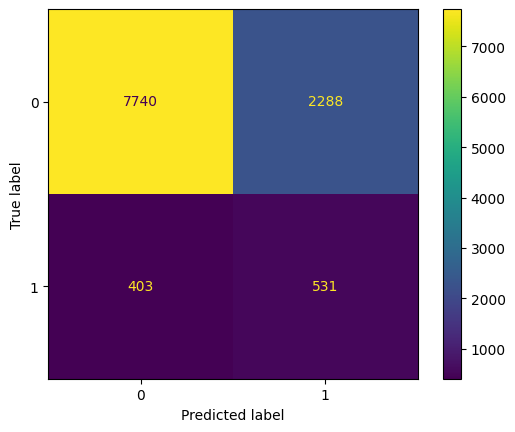

In [69]:
from sklearn.metrics import ConfusionMatrixDisplay

ConfusionMatrixDisplay.from_predictions(
    y_test, y_pred, display_labels=log_model.classes_
)
plt.show()

k Nearest Neighbours

In [70]:
metric_k = []
neighbours = np.arange(3, 20)

for i in neighbours:
  knn_model = KNeighborsClassifier(n_neighbors=i, n_jobs=-1)
  knn_model.fit(x_train_resampled, y_train_resampled)
  y_pred_knn = knn_model.predict(x_test)
  metric_k.append(accuracy_score(y_test, y_pred_knn))

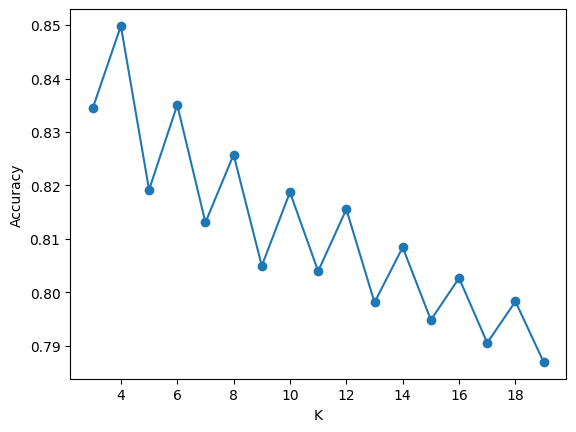

In [71]:
plt.plot(neighbours,metric_k,marker='o')
plt.xlabel('K')
plt.ylabel('Accuracy')
plt.show()

In [72]:
knn_classifier = KNeighborsClassifier(n_neighbors=11)
knn_classifier.fit(x_train_resampled, y_train_resampled)
y_pred_knn = knn_classifier.predict(x_test)

print("F1 Score: ", f1_score(y_test, y_pred_knn))
print("Confusion Matrix:\n", confusion_matrix(y_test, y_pred_knn))

F1 Score:  0.32864729771946266
Confusion Matrix:
 [[8287 1741]
 [ 408  526]]


Random Forest

In [73]:
rf_model = RandomForestClassifier(random_state=42)
rf_model.fit(x_train_resampled, y_train_resampled)
y_pred_rf = rf_model.predict(x_test)

print('F1 Score :', f1_score(y_test, y_pred_rf))
print(confusion_matrix(y_test, y_pred_rf))

F1 Score : 0.41662169454937936
[[9495  533]
 [ 548  386]]


In [74]:
rf_model.get_params()

{'bootstrap': True,
 'ccp_alpha': 0.0,
 'class_weight': None,
 'criterion': 'gini',
 'max_depth': None,
 'max_features': 'sqrt',
 'max_leaf_nodes': None,
 'max_samples': None,
 'min_impurity_decrease': 0.0,
 'min_samples_leaf': 1,
 'min_samples_split': 2,
 'min_weight_fraction_leaf': 0.0,
 'monotonic_cst': None,
 'n_estimators': 100,
 'n_jobs': None,
 'oob_score': False,
 'random_state': 42,
 'verbose': 0,
 'warm_start': False}

In [75]:
rf_model = RandomForestClassifier(random_state=42, n_estimators=200, n_jobs=-1)

rf_model.fit(x_train_resampled, y_train_resampled)
y_pred_rf = rf_model.predict(x_test)

print('F1 Score :', f1_score(y_test, y_pred_rf))
print(confusion_matrix(y_test, y_pred_rf))

F1 Score : 0.4129380053908356
[[9490  538]
 [ 551  383]]


Best Model Random Forest - 41 F1-Score

Best Parameters: {'n_estimators': 300, 'min_samples_split': 2, 'min_samples_leaf': 1, 'max_depth': 30, 'bootstrap': True}
Best F1 Score: 0.9383262433372757
F1 Score : 0.4078879086663207
              precision    recall  f1-score   support

           0       0.95      0.94      0.94     10028
           1       0.40      0.42      0.41       934

    accuracy                           0.90     10962
   macro avg       0.67      0.68      0.68     10962
weighted avg       0.90      0.90      0.90     10962



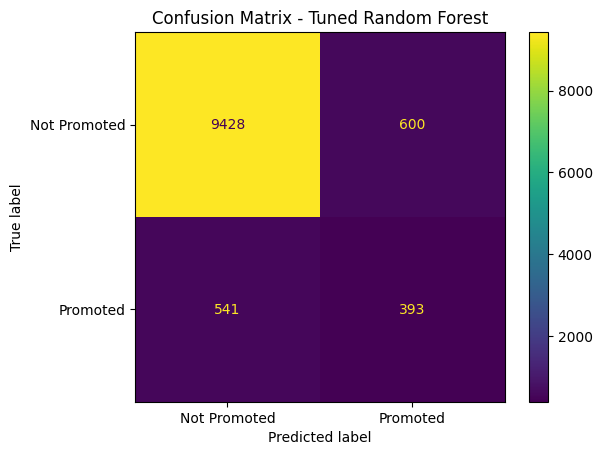

In [76]:
from sklearn.model_selection import RandomizedSearchCV

# Balanced parameter grid to find stable combinations without heavy overfitting
param_distributions = {
    'n_estimators': [100, 200, 300],
    'max_depth': [None, 10, 20, 30],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf': [1, 2, 4],
    'bootstrap': [True]  # Keeps bootstrapping enabled so trees regularize better
}

rf_random_search = RandomizedSearchCV(
    estimator=RandomForestClassifier(random_state=42),
    param_distributions=param_distributions,
    n_iter=10,                 # Back to 10 iterations for a better search
    cv=3,                      # Keep 3 folds for safe memory usage
    scoring='f1',
    random_state=42,
    n_jobs=2                   # Limits workers to avoid crash
)

rf_random_search.fit(x_train_resampled, y_train_resampled)

print("Best Parameters:", rf_random_search.best_params_)
print("Best F1 Score:", rf_random_search.best_score_)

best_rf_model = rf_random_search.best_estimator_
y_pred_rf_tuned = best_rf_model.predict(x_test)

print('F1 Score :', f1_score(y_test, y_pred_rf_tuned))
print(classification_report(y_test, y_pred_rf_tuned))

ConfusionMatrixDisplay.from_predictions(
    y_test, y_pred_rf_tuned, display_labels=['Not Promoted', 'Promoted']
)
plt.title('Confusion Matrix - Tuned Random Forest')
plt.show()

**T E S T I N G**

In [77]:
print(test.shape)
print(test.head())
print(test.dtypes)

(23490, 13)
   employee_id         department     region   education gender  \
0         8724         Technology  region_26  Bachelor's      m   
1        74430                 HR   region_4  Bachelor's      f   
2        72255  Sales & Marketing  region_13  Bachelor's      m   
3        38562        Procurement   region_2  Bachelor's      f   
4        64486            Finance  region_29  Bachelor's      m   

  recruitment_channel  no_of_trainings  age  previous_year_rating  \
0            sourcing                1   24                   NaN   
1               other                1   31                   3.0   
2               other                1   31                   1.0   
3               other                3   31                   2.0   
4            sourcing                1   30                   4.0   

   length_of_service  KPIs_met >80%  awards_won?  avg_training_score  
0                  1              1            0                  77  
1                  5        

In [78]:
# Check missing values in test data
print(test.isnull().sum())

employee_id                0
department                 0
region                     0
education               1034
gender                     0
recruitment_channel        0
no_of_trainings            0
age                        0
previous_year_rating    1812
length_of_service          0
KPIs_met >80%              0
awards_won?                0
avg_training_score         0
dtype: int64


In [79]:
# Check duplicated rows in test data
print(test.duplicated().sum())

0


In [80]:
test['employee_id'].value_counts()

,count
employee_id,
5973,1
8724,1
67979,1
29379,1
59625,1
...,...
54542,1
46232,1
64486,1


In [81]:
# Drop column employee_id
test.drop('employee_id', axis=1, inplace=True)

In [82]:
test.head()

,department,region,education,gender,recruitment_channel,no_of_trainings,age,previous_year_rating,length_of_service,KPIs_met >80%,awards_won?,avg_training_score
0,Technology,region_26,Bachelor's,m,sourcing,1,24,NaN,1,1,0,77
1,HR,region_4,Bachelor's,f,other,1,31,3.0,5,0,0,51
2,Sales & Marketing,region_13,Bachelor's,m,other,1,31,1.0,4,0,0,47
3,Procurement,region_2,Bachelor's,f,other,3,31,2.0,9,0,0,65
4,Finance,region_29,Bachelor's,m,sourcing,1,30,4.0,7,0,0,61


In [83]:
test['education'] = test['education'].fillna(education_mode)
test['previous_year_rating'] = test['previous_year_rating'].fillna(rating_median)

In [84]:
# Encoding categorical variables in test data
test['gender'] = test['gender'].map({'m': 0, 'f': 1})
test['education'] = test['education'].map(education_mapping)

# Target encoding for 'region' using the fitted encoder from train
test['region'] = encoder.transform(test[['region']])

# One-hot encoding for test dataset
test = pd.get_dummies(
    test,
    columns=['recruitment_channel', 'department'],
    drop_first=True,
    dtype=int,
)



In [85]:
# Align columns to match the training features layout precisely
missing_cols = set(x_train.columns) - set(test.columns)
for c in missing_cols:
  test[c] = 0
test = test[x_train.columns]

Above cell -> When pd.get_dummies() runs on the train and test sets independently, any category that exists in the training set but is completely absent from the test set rows will result in a missing column in your test dataframe.

In [86]:
# Scaling numerical columns in test dataset using the training scaler
test[scale_cols] = scaler.transform(test[scale_cols])

In [87]:
# Generate predictions using the best tuned model
test_predictions = best_rf_model.predict(test)

In [89]:
# Prepare the final submission file as per the problem statement
sample['is_promoted'] = test_predictions
sample.to_csv('/content/drive/MyDrive/DSA/Case study/hr_analytics_final_submission.csv', index=False)

In [90]:
print('Submission file successfully created and saved!')
print(sample['is_promoted'].value_counts())

Submission file successfully created and saved!
is_promoted
0    21207
1     2283
Name: count, dtype: int64
